# Spark Session

In [1]:
import os, pickle, glob
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, length, trim, lower
import matplotlib.pyplot as plt

Matplotlib created a temporary cache directory at /scratch/gkao/job_48545850/matplotlib-0vh0136c because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# spark session builder
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "10g") \
    .config('spark.executor.instances', 15) \
    .getOrCreate()

# Exploratory Data Analysis

In [3]:
# load dataset
df = spark.read.csv('shared/', header=True)
df.describe()

DataFrame[summary: string, title: string, post_id: string, over_18: string, subreddit: string, link_flair_text: string, self_text: string]

In [4]:
df.show(5)

+--------------------+-------+-------+--------------------+---------------+--------------------+
|               title|post_id|over_18|           subreddit|link_flair_text|           self_text|
+--------------------+-------+-------+--------------------+---------------+--------------------+
|Pokémon is SO 199...| tt4ppj|  false|   TheFriendlyHermit|           NULL|           [removed]|
|Looking for peopl...| ttdavv|  false|  MakeNewFriendsHere|           NULL|           [deleted]|
|VIDEO Zelensky sp...| ttdavw|  false|             ukraine|            WAR|                NULL|
|first knife in ma...| ttdavy|  false|              knives|           NULL|"Amazon will deli...|
|come on, what do ...| ttdavz|  false|IThinkYouShouldLeave|           NULL|                NULL|
+--------------------+-------+-------+--------------------+---------------+--------------------+
only showing top 5 rows



In [5]:
# check how many rows and columns we have
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 654221435
Columns: 6


In [6]:
# count null or empty values
empty_or_null_df = df.select([
    count(when(col(c).isNull() | (col(c) == ""), 1)).alias(c)
    for c in df.columns
])

empty_or_null_df.show()

+-----+-------+-------+---------+---------------+---------+
|title|post_id|over_18|subreddit|link_flair_text|self_text|
+-----+-------+-------+---------+---------------+---------+
|  336|  17933|  20405|    21505|      425449504|345790643|
+-----+-------+-------+---------+---------------+---------+



In [7]:
# see number of unique subreddits
df.select("subreddit").distinct().count()

6857314

In [4]:
# top subreddits by number of posts
groupby_sub = df.groupBy("subreddit") \
  .count() \
  .orderBy(col("count").desc())
groupby_sub.show(20, truncate=False)

+-------------------+-------+
|subreddit          |count  |
+-------------------+-------+
|AskReddit          |6139237|
|dirtykikpals       |3501877|
|GaySnapchat        |3095930|
|dirtyr4r           |3029756|
|jerkbudss          |2341773|
|FreeKarma4U        |2284238|
|teenagers          |2191354|
|DirtySnapchat      |1895438|
|memes              |1686406|
|AutoNewspaper      |1571969|
|onlyfansgirls101   |1454296|
|relationship_advice|1448498|
|MassiveCock        |1424096|
|cock               |1303653|
|gonewild           |1302379|
|FemBoys            |1300658|
|PokemonGoRaids     |1289534|
|NSFW_Tributes      |1217304|
|dirtypenpals       |1213695|
|FreeKarma4You      |1208657|
+-------------------+-------+
only showing top 20 rows



In [17]:
# distribution of subreddit entry counts

# convert to pandas
groupby_sub_pd = groupby_sub.toPandas()

# distribution of subreddit entries count
# 75% of the subreddits have less than 3 entries 
groupby_sub_pd.describe()

,count
count,6.857314e+06
mean,9.540491e+01
std,5.258662e+03
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,3.000000e+00
max,6.139237e+06


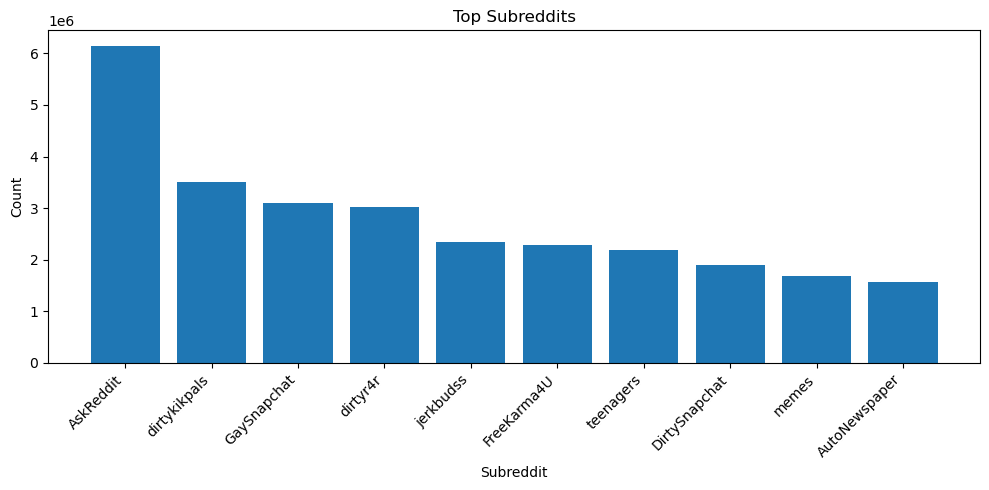

In [5]:
# get top 10 subreddits
top_subreddits = groupby_sub.limit(10)

# convert to pandas for plotting
top_subreddits_pd = top_subreddits.toPandas()

# plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(top_subreddits_pd["subreddit"], top_subreddits_pd["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Subreddits")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

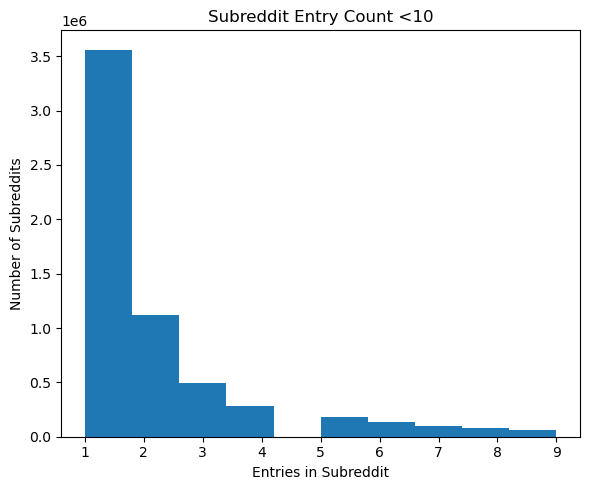

In [28]:
# subreddits with <10 entries
sub_less10_pd = groupby_sub_pd[groupby_sub_pd['count']<10]

# plot bar chart
plt.figure(figsize=(6, 5))
plt.hist(sub_less10_pd['count'])
plt.title("Subreddit Entry Count <10")
plt.xlabel("Entries in Subreddit")
plt.ylabel("Number of Subreddits")
plt.tight_layout()
plt.savefig("subreddit_hist1.png", bbox_inches="tight")
plt.show()

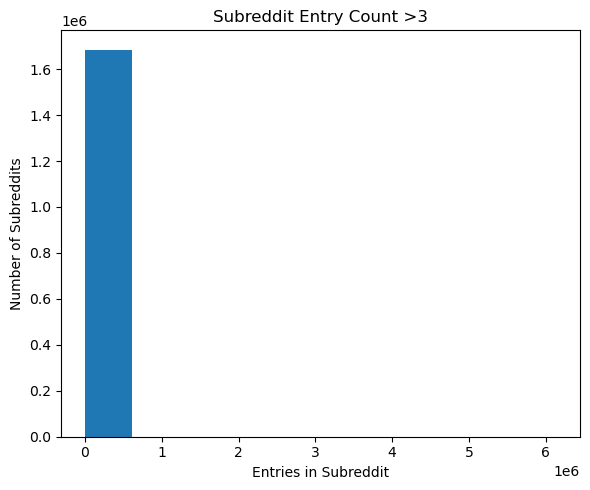

In [29]:
# subreddits with >1000 entries
sub_more10_pd = groupby_sub_pd[groupby_sub_pd['count']>3]

# plot bar chart
plt.figure(figsize=(6, 5))
plt.hist(sub_more10_pd['count'])
plt.title("Subreddit Entry Count >3")
plt.xlabel("Entries in Subreddit")
plt.ylabel("Number of Subreddits")
plt.tight_layout()
plt.savefig("subreddit_hist2.png", bbox_inches="tight")
plt.show()

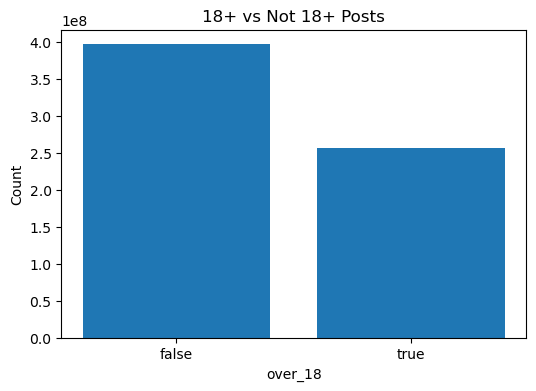

In [27]:
# clean over_18 values and keep only true/false
df_over18 = df.withColumn("over_18_clean", lower(trim(col("over_18")))) \
              .filter(col("over_18_clean").isin("true", "false"))

# count valid true/false values
over18_counts = df_over18.groupBy("over_18_clean").count()

# convert tiny result to pandas
over18_pd = over18_counts.toPandas()

# plot
plt.figure(figsize=(6, 4))
plt.bar(over18_pd["over_18_clean"], over18_pd["count"])
plt.title("18+ vs Not 18+ Posts")
plt.xlabel("over_18")
plt.ylabel("Count")
plt.show()

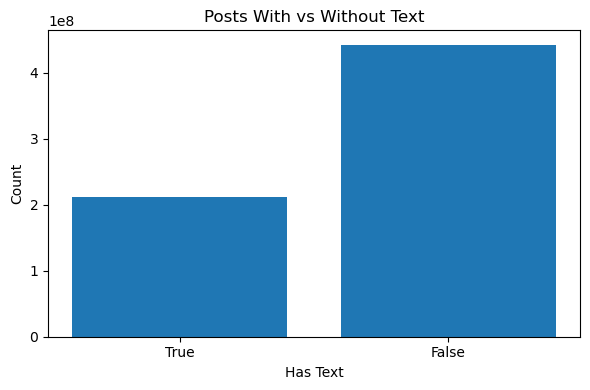

In [11]:
# classify posts
df_text = df.withColumn(
    "has_text",
    col("self_text").isNotNull() & (col("self_text") != "") & (col("self_text") != "[removed]")
)

text_counts = df_text.groupBy("has_text").count()

text_pd = text_counts.toPandas()

plt.figure(figsize=(6,4))
plt.bar(text_pd["has_text"].astype(str), text_pd["count"])
plt.title("Posts With vs Without Text")
plt.xlabel("Has Text")
plt.ylabel("Count")
plt.tight_layout()
# plt.savefig("text_presence.png", bbox_inches="tight")
plt.show()

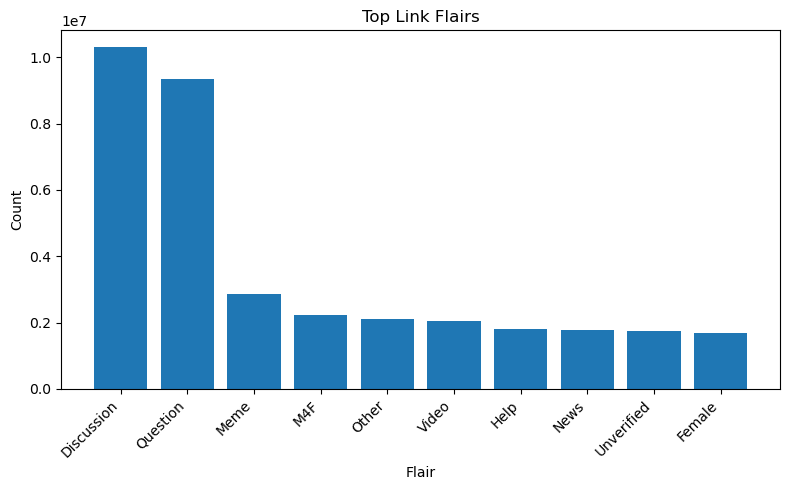

In [12]:
# filter out null flairs first
df_flair = df.filter(col("link_flair_text").isNotNull())

top_flairs = df_flair.groupBy("link_flair_text") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

top_flairs_pd = top_flairs.toPandas()

plt.figure(figsize=(8,5))
plt.bar(top_flairs_pd["link_flair_text"], top_flairs_pd["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Link Flairs")
plt.xlabel("Flair")
plt.ylabel("Count")
plt.tight_layout()
# plt.savefig("top_flairs.png", bbox_inches="tight")
plt.show()